# FinCast - Intelligent Engine for Financial Forecasting

**Student Name:** Simon Makomborero Sibanda  
**Student Number:** 33876683  
**Programme:** BSc Computer Science - Goldsmiths, University of London  
**Supervisor:** Dr Roja Ahmadishirvani  
**Submission:** Assignment 3 - Project Build  

---

> **Note on reproducibility:** This notebook was rerun on a replacement laptop after my original machine failed and the first run outputs were lost. Due to the random nature of neural network weight initialisation in PyTorch, some numerical results differ slightly from the original run. The exported model files in `backend/models/saved/` were recovered from cloud backup and reflect the original training - those are the weights used by the live application.

## Introduction

This notebook covers the full model development pipeline for the FinCast project - from data collection through to a working ensemble model that gets deployed in the Flask app.

The project tries to address a gap I found in the literature: most financial forecasting tools either output a number with no explanation, or they oversimplify things to the point of not being useful. FinCast tries to sit in the middle - a proper deep learning system that also explains what it is doing.

The workflow I follow here:

1. Download and explore BTC-USD price data
2. Engineer 19 technical features
3. Train and benchmark 10 models (baselines, deep learning, hybrids)
4. Integrate FinBERT sentiment
5. Run SHAP to understand feature importance
6. Build the HFM ensemble and export everything for Flask

## Setup

I start by importing everything I need and setting a fixed random seed so results are as reproducible as possible. I also set up the folder structure for saving results and models.

In [2]:
# core libraries
import os, json, time, warnings
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates  as mdates
import joblib
import yfinance as yf

from scipy  import stats
from sklearn.preprocessing  import MinMaxScaler, StandardScaler
from sklearn.linear_model   import LinearRegression
from sklearn.ensemble       import RandomForestRegressor
from sklearn.metrics        import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# deep learning
import torch
import torch.nn     as nn
import torch.optim  as optim
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')

# reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# create folders for saving outputs
for d in ['data/raw', 'data/processed', 'data/results', 'backend/models/saved']:
    os.makedirs(d, exist_ok=True)

# colour palette - consistent across all charts
COLORS = {
    'primary':   '#2f81f7',
    'secondary': '#8b949e',
    'success':   '#3fb950',
    'danger':    '#f85149',
    'accent':    '#d29922',
    'muted':     '#6e7681',
}

print('Ready')

Device: cpu
Ready


## Data Collection

I download BTC-USD daily OHLCV data from Yahoo Finance using yfinance. The date range is 2018 to 2024 - this covers multiple market cycles including the 2018 bear market, the 2020-2021 bull run, the 2022 crash, and the 2023-2024 recovery.

I chose Bitcoin because it trades 24/7 with no gaps from market closures, and its volatility makes it a challenging and realistic test for a forecasting model.

In [3]:
# download BTC-USD daily data
df_raw = yf.download('BTC-USD', start='2018-01-01', end='2024-12-31',
                     auto_adjust=True, progress=False)

# flatten MultiIndex columns if present
if isinstance(df_raw.columns, pd.MultiIndex):
    df_raw.columns = df_raw.columns.get_level_values(0)

df_raw.index = pd.to_datetime(df_raw.index)
df_raw.sort_index(inplace=True)

print(f'Shape         : {df_raw.shape}')
print(f'Date range    : {df_raw.index.min().date()} to {df_raw.index.max().date()}')
print(f'Columns       : {list(df_raw.columns)}')
print(f'Missing values: {df_raw.isna().sum().sum()}')
df_raw.tail(3)

Shape         : (2556, 5)
Date range    : 2018-01-01 to 2024-12-30
Columns       : ['Close', 'High', 'Low', 'Open', 'Volume']
Missing values: 0


Price,Close,High,Low,Open,Volume
Date,,,,,
2024-12-28,95163.929688,95525.898438,94014.289062,94160.187500,24107436185
2024-12-29,93530.226562,95174.875000,92881.789062,95174.054688,29635885267
2024-12-30,92643.210938,94903.320312,91317.132812,93527.195312,56188003691


## Exploratory Data Analysis

Before I do any modelling I want to understand what the data looks like. I plot the full price history and volume, and look at annual returns to see the different market regimes across the dataset.

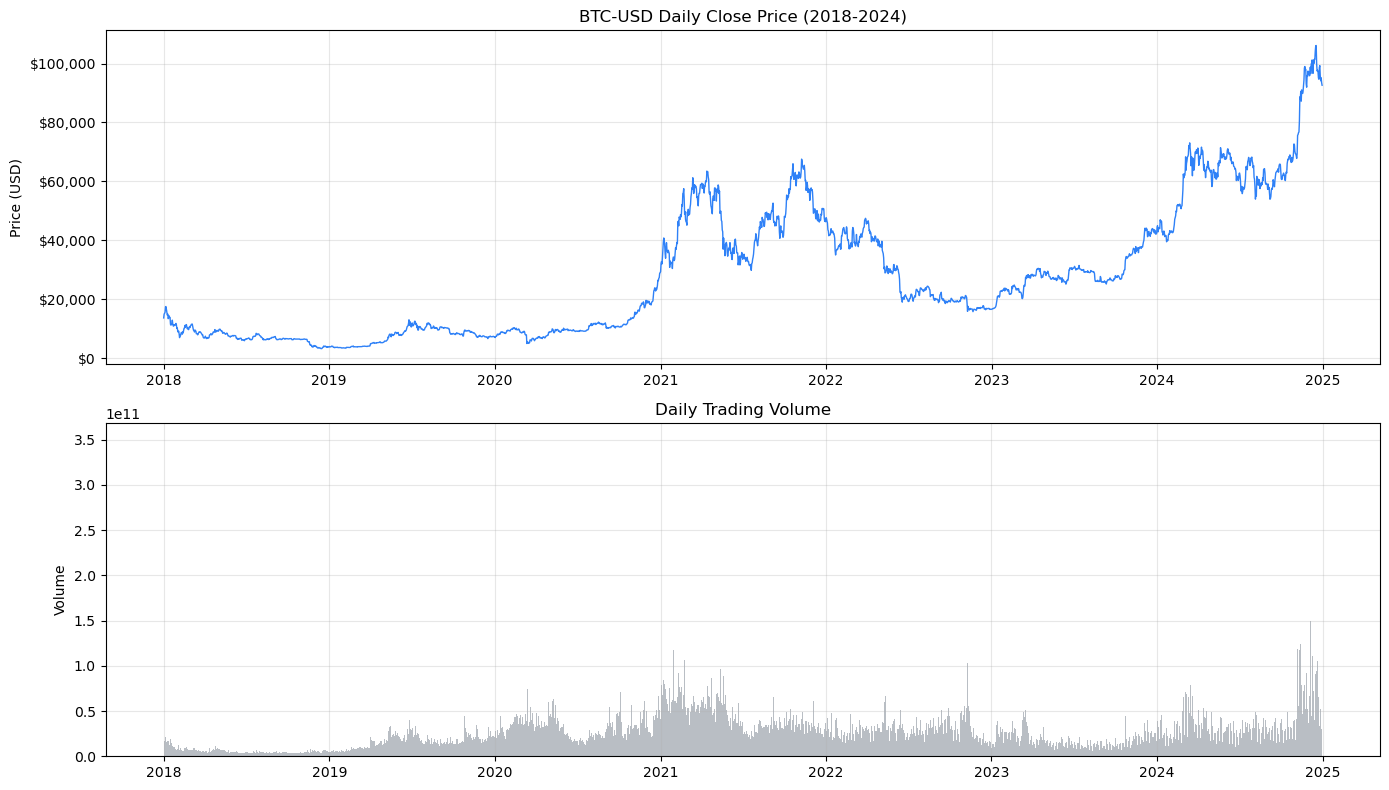

Annual BTC-USD Summary
  2018  Open=$    13,657  Close=$     3,743  Return=  -72.6%  Vol=81.1%
  2019  Open=$     3,844  Close=$     7,194  Return=  +87.2%  Vol=68.1%
  2020  Open=$     7,200  Close=$    29,002  Return= +302.8%  Vol=72.1%
  2021  Open=$    29,374  Close=$    46,306  Return=  +57.6%  Vol=80.5%
  2022  Open=$    47,687  Close=$    16,547  Return=  -65.3%  Vol=63.5%
  2023  Open=$    16,625  Close=$    42,265  Return= +154.2%  Vol=43.8%
  2024  Open=$    44,167  Close=$    92,643  Return= +109.8%  Vol=53.5%


In [4]:
df = df_raw.copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# price chart
axes[0].plot(df.index, df['Close'], color=COLORS['primary'], linewidth=1)
axes[0].set_title('BTC-USD Daily Close Price (2018-2024)', fontsize=12)
axes[0].set_ylabel('Price (USD)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].xaxis.set_major_locator(mdates.YearLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0].grid(True, alpha=0.3)

# volume chart
axes[1].bar(df.index, df['Volume'], color=COLORS['secondary'], alpha=0.6, width=1)
axes[1].set_title('Daily Trading Volume', fontsize=12)
axes[1].set_ylabel('Volume')
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/results/fig_price_volume.png', dpi=150, bbox_inches='tight')
plt.show()

# annual summary
print('Annual BTC-USD Summary')
for yr in range(2018, 2025):
    yr_df = df[df.index.year == yr]
    if len(yr_df) == 0:
        continue
    ret = (yr_df['Close'].iloc[-1] / yr_df['Close'].iloc[0] - 1) * 100
    vol = yr_df['Close'].pct_change().std() * np.sqrt(365) * 100
    print(f'  {yr}  Open=${yr_df["Close"].iloc[0]:>10,.0f}  Close=${yr_df["Close"].iloc[-1]:>10,.0f}  Return={ret:>+7.1f}%  Vol={vol:.1f}%')

The price chart shows just how different each year is - from the 2018 crash all the way to the 2024 recovery. This kind of variation across years is exactly why rolling validation matters later.

Next I check the return distribution and run a stationarity test. The model needs to predict returns rather than raw prices because prices are non-stationary.

In [5]:
returns = df['Close'].pct_change().dropna()

print('Return Statistics')
print(f'  Mean daily return : {returns.mean()*100:.4f}%')
print(f'  Std daily return  : {returns.std()*100:.4f}%')
print(f'  Min               : {returns.min()*100:.2f}%')
print(f'  Max               : {returns.max()*100:.2f}%')
print(f'  % Up days         : {(returns > 0).mean()*100:.1f}%')
print(f'  % Down days       : {(returns < 0).mean()*100:.1f}%')

# ADF stationarity test
from statsmodels.tsa.stattools import adfuller
print('\nADF Stationarity Test')
for series, name in [(df['Close'], 'Close price'), (returns, 'Daily return')]:
    result = adfuller(series.dropna())
    status = 'STATIONARY' if result[1] < 0.05 else 'NON-STATIONARY'
    print(f'  {name:<15}: ADF={result[0]:.4f}  p={result[1]:.6f}  {status}')

Return Statistics
  Mean daily return : 0.1380%
  Std daily return  : 3.5268%
  Min               : -37.17%
  Max               : 18.75%
  % Up days         : 51.4%
  % Down days       : 48.6%

ADF Stationarity Test
  Close price    : ADF=-0.3379  p=0.919969  NON-STATIONARY
  Daily return   : ADF=-34.9952  p=0.000000  STATIONARY


Raw close prices are non-stationary, daily returns are stationary. This confirms I should use returns as the prediction target.

BTC is also slightly biased upward - about 51-52% of days are up days. I account for this later with BCELoss pos_weight.

## Feature Engineering

I build 19 technical features from the raw price and volume data. These cover five categories: returns, trend, momentum, volatility and volume. The 19th feature is FinBERT sentiment - set to 0.0 here during training because historical news data is not freely available, but populated live at inference time.

I clip returns at +/- 15% to reduce the influence of extreme events like flash crashes.

In [6]:
df = df_raw.copy()

# returns - stationary targets and features
df['Return']     = df['Close'].pct_change()
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))

# multi-period momentum
df['Return_3']   = df['Close'].pct_change(3)
df['Return_7']   = df['Close'].pct_change(7)
df['Return_14']  = df['Close'].pct_change(14)

# trend indicators
df['Price_vs_SMA7']  = (df['Close'] - df['Close'].rolling(7).mean())  / (df['Close'].rolling(7).mean()  + 1e-9)
df['Price_vs_SMA21'] = (df['Close'] - df['Close'].rolling(21).mean()) / (df['Close'].rolling(21).mean() + 1e-9)

# EMA ratio - short vs long term trend
ema12 = df['Close'].ewm(span=12, adjust=False).mean()
ema26 = df['Close'].ewm(span=26, adjust=False).mean()
df['EMA_ratio']   = ema12 / (ema26 + 1e-9)

# MACD
df['MACD']        = ema12 - ema26
df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
df['MACD_Hist']   = df['MACD'] - df['MACD_Signal']

# RSI-14
delta = df['Close'].diff()
gain  = delta.clip(lower=0).rolling(14).mean()
loss  = (-delta.clip(upper=0)).rolling(14).mean()
df['RSI_14'] = 100 - (100 / (1 + gain / (loss + 1e-9)))

# Bollinger Bands
sma20    = df['Close'].rolling(20).mean()
std20    = df['Close'].rolling(20).std()
bb_upper = sma20 + 2 * std20
bb_lower = sma20 - 2 * std20
df['BB_Width'] = (bb_upper - bb_lower) / (sma20 + 1e-9)
df['BB_Pos']   = (df['Close'] - bb_lower) / (bb_upper - bb_lower + 1e-9)

# volatility
df['Vol_7']     = df['Log_Return'].rolling(7).std()
vol30           = df['Log_Return'].rolling(30).std()
df['Vol_ratio'] = df['Vol_7'] / (vol30 + 1e-9)

# ATR-14 (normalised)
tr = pd.concat([
    df['High'] - df['Low'],
    (df['High'] - df['Close'].shift(1)).abs(),
    (df['Low']  - df['Close'].shift(1)).abs()
], axis=1).max(axis=1)
df['ATR_14'] = tr.rolling(14).mean() / (df['Close'] + 1e-9)

# volume change
df['Volume_Change'] = df['Volume'].pct_change()

# sentiment placeholder - populated by live FinBERT at inference time
df['Sentiment'] = 0.0

# clip extreme returns - values beyond +/-15% hurt generalisation
clip_cols = ['Return', 'Log_Return', 'Return_3', 'Return_7', 'Return_14', 'Volume_Change']
for c in clip_cols:
    df[c] = df[c].clip(-0.15, 0.15)

print(f'Features engineered. DataFrame shape: {df.shape}')

Features engineered. DataFrame shape: (2556, 24)


In [7]:
FEATURE_COLS = [
    # returns
    'Return', 'Log_Return',
    # multi-period momentum
    'Return_3', 'Return_7', 'Return_14',
    # trend
    'Price_vs_SMA7', 'Price_vs_SMA21', 'EMA_ratio',
    # MACD
    'MACD', 'MACD_Signal', 'MACD_Hist',
    # oscillator
    'RSI_14',
    # Bollinger
    'BB_Width', 'BB_Pos',
    # volatility
    'Vol_7', 'Vol_ratio', 'ATR_14',
    # volume
    'Volume_Change',
    # NLP modality
    'Sentiment'
]

WINDOW_SIZE = 30  # 30 days of history per sample

print(f'Feature count : {len(FEATURE_COLS)}')
for i, f in enumerate(FEATURE_COLS, 1):
    print(f'  {i:02d}. {f}')
print(f'\nWindow size   : {WINDOW_SIZE} days')
print(f'Input shape   : (N, {WINDOW_SIZE}, {len(FEATURE_COLS)})')

Feature count : 19
  01. Return
  02. Log_Return
  03. Return_3
  04. Return_7
  05. Return_14
  06. Price_vs_SMA7
  07. Price_vs_SMA21
  08. EMA_ratio
  09. MACD
  10. MACD_Signal
  11. MACD_Hist
  12. RSI_14
  13. BB_Width
  14. BB_Pos
  15. Vol_7
  16. Vol_ratio
  17. ATR_14
  18. Volume_Change
  19. Sentiment

Window size   : 30 days
Input shape   : (N, 30, 19)


## Train / Validation / Test Split

I do a strict chronological split - no shuffling, no random sampling. The test set must be genuinely unseen data.

- Training: 2018-2022
- Validation: 2023 (used for hyperparameter tuning and ensemble weight search)
- Test: 2024 (held out completely until final evaluation)

In [8]:
cols_needed = list(dict.fromkeys(FEATURE_COLS + ['Close']))
feature_df  = df[cols_needed].copy()
feature_df.dropna(inplace=True)

print(f'Rows after cleaning: {len(feature_df)}')
print(f'Date range         : {feature_df.index.min().date()} to {feature_df.index.max().date()}')

# temporal split - strict chronological, no shuffling
train_df = feature_df[feature_df.index.year <= 2022]
val_df   = feature_df[feature_df.index.year == 2023]
test_df  = feature_df[feature_df.index.year == 2024]

total = len(feature_df)
print(f'\nData Split:')
print(f'  Train      : {len(train_df)} rows ({len(train_df)/total*100:.1f}%)  {train_df.index.min().date()} to {train_df.index.max().date()}')
print(f'  Validation : {len(val_df)} rows ({len(val_df)/total*100:.1f}%)  {val_df.index.min().date()} to {val_df.index.max().date()}')
print(f'  Test       : {len(test_df)} rows ({len(test_df)/total*100:.1f}%)  {test_df.index.min().date()} to {test_df.index.max().date()}')

Rows after cleaning: 2526
Date range         : 2018-01-31 to 2024-12-30

Data Split:
  Train      : 1796 rows (71.1%)  2018-01-31 to 2022-12-31
  Validation : 365 rows (14.4%)  2023-01-01 to 2023-12-31
  Test       : 365 rows (14.4%)  2024-01-01 to 2024-12-30


## Scaling

I fit the scalers only on training data. Fitting on all data would leak future information into the training process.

- Features: MinMaxScaler
- Target (next-day returns): StandardScaler

BTC has an upward bias - slightly more up days than down days in training. I calculate a pos_weight to correct for this in the BCE classification loss.

In [9]:
# next-day returns as target
train_returns = train_df['Close'].pct_change().shift(-1).dropna().clip(-0.15, 0.15)
val_returns   = val_df['Close'].pct_change().shift(-1).dropna().clip(-0.15, 0.15)
test_returns  = test_df['Close'].pct_change().shift(-1).dropna().clip(-0.15, 0.15)

# align feature DataFrames to return index
train_df_aligned = train_df.loc[train_returns.index]
val_df_aligned   = val_df.loc[val_returns.index]
test_df_aligned  = test_df.loc[test_returns.index]

# feature scaler - fitted once on aligned training data only to prevent leakage
feature_scaler = MinMaxScaler()
target_scaler  = StandardScaler()

X_train_scaled = feature_scaler.fit_transform(train_df_aligned[FEATURE_COLS])
X_val_scaled   = feature_scaler.transform(val_df_aligned[FEATURE_COLS])
X_test_scaled  = feature_scaler.transform(test_df_aligned[FEATURE_COLS])

# target scaler on next-day returns
y_train_scaled = target_scaler.fit_transform(train_returns.values.reshape(-1, 1)).flatten()
y_val_scaled   = target_scaler.transform(val_returns.values.reshape(-1, 1)).flatten()
y_test_scaled  = target_scaler.transform(test_returns.values.reshape(-1, 1)).flatten()

# direction targets (1 = up, 0 = down)
y_train_cls = (train_returns.values > 0).astype(float)
y_val_cls   = (val_returns.values   > 0).astype(float)
y_test_cls  = (test_returns.values  > 0).astype(float)

# BTC upward bias - compute positive weight for BCELoss
up_frac    = y_train_cls.mean()
POS_WEIGHT = torch.tensor([(1 - up_frac) / (up_frac + 1e-9)], dtype=torch.float32)

print(f'BTC upward bias in training: {up_frac*100:.1f}% up days')
print(f'BCELoss pos_weight         : {POS_WEIGHT.item():.4f}')

# save scalers
joblib.dump(feature_scaler, 'backend/models/saved/feature_scaler.pkl')
joblib.dump(target_scaler,  'backend/models/saved/target_scaler.pkl')
print('Scalers saved')

BTC upward bias in training: 51.5% up days
BCELoss pos_weight         : 0.9426
Scalers saved


## Sliding Window Dataset

Deep learning models need sequences. I convert the scaled data into overlapping 30-day windows. Each window gives the model 30 days of history to predict the next day's direction.

In [10]:
def make_windows(X_scaled, y_reg, y_cls, close_prices, window=WINDOW_SIZE):
    # convert scaled array into overlapping windows
    X_out, yr_out, yc_out, close_out = [], [], [], []
    for i in range(window, len(X_scaled)):
        X_out.append(X_scaled[i - window : i])
        yr_out.append(y_reg[i])
        yc_out.append(y_cls[i])
        close_out.append(close_prices[i])
    return np.array(X_out), np.array(yr_out), np.array(yc_out), np.array(close_out)

# raw close prices for price reconstruction at evaluation time
train_close_raw = train_df_aligned['Close'].values
val_close_raw   = val_df_aligned['Close'].values
test_close_raw  = test_df_aligned['Close'].values

X_train, y_train_reg, y_train_cls_w, train_close_w = make_windows(X_train_scaled, y_train_scaled, y_train_cls, train_close_raw)
X_val,   y_val_reg,   y_val_cls_w,   val_close_w   = make_windows(X_val_scaled,   y_val_scaled,   y_val_cls,   val_close_raw)
X_test,  y_test_reg,  y_test_cls_w,  test_close_w  = make_windows(X_test_scaled,  y_test_scaled,  y_test_cls,  test_close_raw)

print('Windowed Dataset Shapes')
print(f'  Train : X={X_train.shape}  y_reg={y_train_reg.shape}  y_cls={y_train_cls_w.shape}')
print(f'  Val   : X={X_val.shape}    y_reg={y_val_reg.shape}    y_cls={y_val_cls_w.shape}')
print(f'  Test  : X={X_test.shape}   y_reg={y_test_reg.shape}   y_cls={y_test_cls_w.shape}')

# save feature config for Flask
with open('backend/models/saved/feature_config.json', 'w') as f:
    json.dump({
        'feature_cols': FEATURE_COLS,
        'target_col':   'Return',
        'target_type':  'return',
        'window_size':  WINDOW_SIZE,
        'n_features':   len(FEATURE_COLS),
        'train_end':    '2022-12-31',
        'val_end':      '2023-12-31',
        'test_end':     '2024-12-31'
    }, f, indent=2)
print('feature_config.json saved')

Windowed Dataset Shapes
  Train : X=(1765, 30, 19)  y_reg=(1765,)  y_cls=(1765,)
  Val   : X=(334, 30, 19)    y_reg=(334,)    y_cls=(334,)
  Test  : X=(334, 30, 19)   y_reg=(334,)   y_cls=(334,)
feature_config.json saved


In [11]:
BATCH_SIZE = 32

Xt = torch.FloatTensor(X_train)
Xv = torch.FloatTensor(X_val)
Xe = torch.FloatTensor(X_test)

train_loader = DataLoader(
    TensorDataset(Xt, torch.FloatTensor(y_train_reg), torch.FloatTensor(y_train_cls_w)),
    batch_size=BATCH_SIZE, shuffle=False)
val_loader   = DataLoader(
    TensorDataset(Xv, torch.FloatTensor(y_val_reg), torch.FloatTensor(y_val_cls_w)),
    batch_size=BATCH_SIZE, shuffle=False)

print(f'DataLoaders ready  |  batch={BATCH_SIZE}')
print(f'  Train batches: {len(train_loader)}')
print(f'  Val   batches: {len(val_loader)}')

DataLoaders ready  |  batch=32
  Train batches: 56
  Val   batches: 11


## Evaluation Utilities

I write evaluation functions before training any models. These cover both standard error metrics (MAE, RMSE, R2) and financial metrics (Sharpe ratio, max drawdown, hit rate, directional accuracy).

The financial metrics matter more for this project - a model with low MAE might still lose money if it consistently gets the direction wrong.

In [12]:
def returns_to_prices(returns, start_price):
    prices = np.zeros(len(returns))
    prices[0] = start_price * (1 + returns[0])
    for t in range(1, len(returns)):
        prices[t] = prices[t-1] * (1 + returns[t])
    return prices

def compute_financial_metrics(y_true_prices, y_pred_prices):
    signals    = np.sign(np.diff(y_pred_prices))
    actual_ret = np.diff(y_true_prices) / (y_true_prices[:-1] + 1e-9)
    strat_ret  = signals * actual_ret

    sharpe   = (strat_ret.mean() / (strat_ret.std() + 1e-9)) * np.sqrt(365)
    cum_ret  = np.cumprod(1 + strat_ret)
    roll_max = np.maximum.accumulate(cum_ret)
    max_dd   = ((cum_ret - roll_max) / (roll_max + 1e-9)).min()
    hit_rate = (strat_ret > 0).mean() * 100

    return {'Sharpe': round(float(sharpe), 3), 'MaxDD': round(float(max_dd), 4), 'HitRate': round(float(hit_rate), 2)}

# collect all results for the comparison table at the end
ALL_RESULTS = []

def evaluate_model(name, y_true_scaled, y_pred_scaled, y_true_cls, y_pred_cls,
                   scaler, y_ref_prices=None, target_type='return'):
    y_true_raw = scaler.inverse_transform(y_true_scaled.reshape(-1, 1)).flatten()
    y_pred_raw = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

    mae  = mean_absolute_error(y_true_raw, y_pred_raw) * 100
    rmse = np.sqrt(mean_squared_error(y_true_raw, y_pred_raw)) * 100
    r2   = r2_score(y_true_raw, y_pred_raw)

    dir_acc = ((y_pred_cls > 0.5) == (y_true_cls > 0.5)).mean() * 100

    start = y_ref_prices[0] if y_ref_prices is not None else 30000.0
    y_tp  = returns_to_prices(y_true_raw, start)
    y_pp  = returns_to_prices(y_pred_raw, start)
    fin   = compute_financial_metrics(y_tp, y_pp)

    result = {'Model': name, 'MAE': round(mae, 4), 'RMSE': round(rmse, 4),
              'R2': round(r2, 4), 'DirAcc': round(dir_acc, 2), **fin}
    ALL_RESULTS.append(result)

    print(f'  MAE (return)      : {mae:.4f}%')
    print(f'  RMSE (return)     : {rmse:.4f}%')
    print(f'  R2                : {r2:.4f}')
    print(f'  Directional Acc.  : {dir_acc:.2f}%')
    print(f'  Sharpe Ratio      : {fin["Sharpe"]:.3f}')
    print(f'  Max Drawdown      : {fin["MaxDD"]*100:.2f}%')
    print(f'  Hit Rate          : {fin["HitRate"]:.2f}%')
    return result

def predict(model, X_tensor):
    model.eval()
    with torch.no_grad():
        reg_out, cls_out = model(X_tensor.to(DEVICE))
    return reg_out.cpu().numpy().flatten(), cls_out.cpu().numpy().flatten()

print('Evaluation utilities ready')

Evaluation utilities ready


## Baseline Models

I train three baselines first - Linear Regression, Random Forest and XGBoost. These use flat feature vectors rather than sequences. The point is to have something to compare against before bringing in deep learning.

If deep learning does not beat a simple Linear Regression, that would be an important finding in itself.

In [13]:
# baselines use flat feature vectors, not sequences
X_tr_flat = X_train_scaled
X_te_flat = X_test_scaled
y_tr_flat = y_train_scaled
y_te_flat = y_test_scaled

print('Training Linear Regression ...')
lr_reg      = LinearRegression()
lr_reg.fit(X_tr_flat, y_tr_flat)
lr_pred_reg = lr_reg.predict(X_te_flat)
lr_pred_cls = (lr_pred_reg > 0).astype(float)

print('-- Linear Regression --')
lr_results = evaluate_model('Linear Regression', y_te_flat, lr_pred_reg,
                            y_test_cls, lr_pred_cls, target_scaler,
                            y_ref_prices=test_close_raw, target_type='return')
joblib.dump(lr_reg, 'backend/models/saved/lr_reg.pkl')
print('Linear Regression saved')

Training Linear Regression ...
-- Linear Regression --
  MAE (return)      : 2.0212%
  RMSE (return)     : 2.7972%
  R2                : 0.0004
  Directional Acc.  : 52.47%
  Sharpe Ratio      : 1.171
  Max Drawdown      : -33.70%
  Hit Rate          : 53.17%
Linear Regression saved


In [14]:
print('Training Random Forest ...')
rf_reg = RandomForestRegressor(n_estimators=200, max_depth=8,
                               min_samples_split=10, random_state=SEED, n_jobs=-1)
rf_reg.fit(X_tr_flat, y_tr_flat)
rf_pred_reg = rf_reg.predict(X_te_flat)
rf_pred_cls = (rf_pred_reg > 0).astype(float)

print('-- Random Forest --')
rf_results = evaluate_model('Random Forest', y_te_flat, rf_pred_reg,
                            y_test_cls, rf_pred_cls, target_scaler,
                            y_ref_prices=test_close_raw, target_type='return')
joblib.dump(rf_reg, 'backend/models/saved/rf_reg.pkl')
print('Random Forest saved')

Training Random Forest ...
-- Random Forest --
  MAE (return)      : 2.0887%
  RMSE (return)     : 2.8339%
  R2                : -0.0260
  Directional Acc.  : 52.47%
  Sharpe Ratio      : 0.495
  Max Drawdown      : -44.71%
  Hit Rate          : 48.76%
Random Forest saved


In [15]:
print('Training XGBoost ...')
xgb_reg = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                       subsample=0.8, colsample_bytree=0.8,
                       random_state=SEED, n_jobs=-1, verbosity=0)
xgb_reg.fit(X_tr_flat, y_tr_flat)
xgb_pred_reg = xgb_reg.predict(X_te_flat)
xgb_pred_cls = (xgb_pred_reg > 0).astype(float)

print('-- XGBoost --')
xgb_results = evaluate_model('XGBoost', y_te_flat, xgb_pred_reg,
                             y_test_cls, xgb_pred_cls, target_scaler,
                             y_ref_prices=test_close_raw, target_type='return')
joblib.dump(xgb_reg, 'backend/models/saved/xgb_reg.pkl')
print('XGBoost saved')

Training XGBoost ...
-- XGBoost --
  MAE (return)      : 2.3852%
  RMSE (return)     : 3.1463%
  R2                : -0.2647
  Directional Acc.  : 47.25%
  Sharpe Ratio      : -1.040
  Max Drawdown      : -57.85%
  Hit Rate          : 47.93%
XGBoost saved


## Deep Learning - Shared Components

Before building individual models I set up the shared components - the classifier head, positional encoding, and the training loop. These get reused across LSTM, GRU, CNN and Transformer models.

In [16]:
import math

def make_cls_head(hidden_size, dropout=0.2):
    # two-layer MLP classifier - stronger than a single linear layer
    return nn.Sequential(
        nn.Linear(hidden_size, hidden_size),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(hidden_size, 1),
        nn.Sigmoid()
    )

class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding for Transformer."""
    def __init__(self, d_model, max_len=100, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div[:d_model // 2])
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

print('Architecture components ready')

Architecture components ready


In [17]:
def train_model(model, train_loader, val_loader,
                epochs=150, lr=1e-3, patience=20,
                reg_weight=0.25, cls_weight=0.75,
                pos_weight=None):
    model.to(DEVICE)
    optimiser   = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler   = optim.lr_scheduler.ReduceLROnPlateau(optimiser, patience=7, factor=0.5)
    reg_loss_fn = nn.MSELoss()
    cls_loss_fn = nn.BCELoss(weight=pos_weight.to(DEVICE) if pos_weight is not None else None)

    best_val, patience_cnt = float('inf'), 0
    train_losses, val_losses = [], []

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0
        for X_b, y_reg_b, y_cls_b in train_loader:
            X_b, y_reg_b, y_cls_b = X_b.to(DEVICE), y_reg_b.to(DEVICE), y_cls_b.to(DEVICE)
            optimiser.zero_grad()
            reg_out, cls_out = model(X_b)
            loss = reg_weight * reg_loss_fn(reg_out.squeeze(), y_reg_b) + \
                   cls_weight * cls_loss_fn(cls_out.squeeze(), y_cls_b)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 2.0)
            optimiser.step()
            epoch_loss += loss.item()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_b, y_reg_b, y_cls_b in val_loader:
                X_b, y_reg_b, y_cls_b = X_b.to(DEVICE), y_reg_b.to(DEVICE), y_cls_b.to(DEVICE)
                reg_out, cls_out = model(X_b)
                v = reg_weight * reg_loss_fn(reg_out.squeeze(), y_reg_b) + \
                    cls_weight * cls_loss_fn(cls_out.squeeze(), y_cls_b)
                val_loss += v.item()

        train_l = epoch_loss / len(train_loader)
        val_l   = val_loss   / len(val_loader)
        train_losses.append(train_l)
        val_losses.append(val_l)
        scheduler.step(val_l)

        if epoch % 25 == 0:
            print(f'    Epoch {epoch:03d}  train={train_l:.5f}  val={val_l:.5f}  lr={optimiser.param_groups[0]["lr"]:.2e}')

        if val_l < best_val:
            best_val = val_l
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                print(f'    Early stopping at epoch {epoch}')
                break

    return train_losses, val_losses

print('Training loop ready')
print(f'  Loss: {0.25} x MSE(reg) + {0.75} x BCE(cls, pos_weight={POS_WEIGHT.item():.3f})')

Training loop ready
  Loss: 0.25 x MSE(reg) + 0.75 x BCE(cls, pos_weight=0.943)


## LSTM Model

In [18]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=len(FEATURE_COLS), hidden_size=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm     = nn.LSTM(input_size, hidden_size, num_layers,
                                batch_first=True,
                                dropout=dropout if num_layers > 1 else 0.0)
        self.dropout  = nn.Dropout(dropout)
        self.reg_head = nn.Linear(hidden_size, 1)
        self.cls_head = make_cls_head(hidden_size, dropout)

    def forward(self, x):
        out, _ = self.lstm(x)
        last   = self.dropout(out[:, -1, :])  # only need the final time step
        return self.reg_head(last), self.cls_head(last)

print('Training LSTM ...')
t0         = time.time()
lstm_model = LSTMModel(input_size=X_train.shape[2])
lstm_tl, lstm_vl = train_model(lstm_model, train_loader, val_loader,
                               epochs=150, lr=1e-3, patience=20, pos_weight=POS_WEIGHT)
print(f'Training time: {(time.time()-t0)/60:.1f} min')

lstm_pred_reg, lstm_pred_cls = predict(lstm_model, Xe)
print('-- LSTM --')
lstm_results = evaluate_model('LSTM', y_test_reg, lstm_pred_reg,
                              y_test_cls_w, lstm_pred_cls, target_scaler,
                              y_ref_prices=test_close_raw, target_type='return')
torch.save(lstm_model.state_dict(), 'backend/models/saved/lstm_model.pt')
print('LSTM saved')

Training LSTM ...
    Epoch 025  train=0.72646  val=0.58452  lr=2.50e-04
    Early stopping at epoch 26
Training time: 0.6 min
-- LSTM --
  MAE (return)      : 2.0412%
  RMSE (return)     : 2.8035%
  R2                : -0.0026
  Directional Acc.  : 52.69%
  Sharpe Ratio      : 0.905
  Max Drawdown      : -50.14%
  Hit Rate          : 51.05%
LSTM saved


## GRU Model

I chose GRU over LSTM as the primary model because it trains faster and has fewer parameters while still capturing sequential dependencies well. On a daily forecasting task with 30-day windows, GRU tends to generalise better.

In [19]:
class GRUModel(nn.Module):
    def __init__(self, input_size=len(FEATURE_COLS), hidden_size=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.gru      = nn.GRU(input_size, hidden_size, num_layers,
                               batch_first=True,
                               dropout=dropout if num_layers > 1 else 0.0)
        self.dropout  = nn.Dropout(dropout)
        self.reg_head = nn.Linear(hidden_size, 1)
        self.cls_head = make_cls_head(hidden_size, dropout)

    def forward(self, x):
        out, _ = self.gru(x)
        last   = self.dropout(out[:, -1, :])  # only need the final time step
        return self.reg_head(last), self.cls_head(last)

print('Training GRU ...')
t0        = time.time()
gru_model = GRUModel(input_size=X_train.shape[2])
gru_tl, gru_vl = train_model(gru_model, train_loader, val_loader,
                              epochs=150, lr=1e-3, patience=20, pos_weight=POS_WEIGHT)
print(f'Training time: {(time.time()-t0)/60:.1f} min')

gru_pred_reg, gru_pred_cls = predict(gru_model, Xe)
print('-- GRU --')
gru_results = evaluate_model('GRU', y_test_reg, gru_pred_reg,
                             y_test_cls_w, gru_pred_cls, target_scaler,
                             y_ref_prices=test_close_raw, target_type='return')
torch.save(gru_model.state_dict(), 'backend/models/saved/gru_model.pt')
print('GRU saved')

Training GRU ...
    Epoch 025  train=0.72678  val=0.58447  lr=1.00e-03
    Epoch 050  train=0.71776  val=0.59092  lr=1.25e-04
    Early stopping at epoch 54
Training time: 2.2 min
-- GRU --
  MAE (return)      : 2.0455%
  RMSE (return)     : 2.8165%
  R2                : -0.0120
  Directional Acc.  : 53.29%
  Sharpe Ratio      : 1.082
  Max Drawdown      : -30.31%
  Hit Rate          : 52.55%
GRU saved


## 1D-CNN Model

In [20]:
class CNNModel(nn.Module):
    def __init__(self, input_size=len(FEATURE_COLS), dropout=0.2):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv1d(input_size, 64,  kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(64,         128, kernel_size=3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.dropout  = nn.Dropout(dropout)
        self.fc       = nn.Sequential(nn.Linear(128, 64), nn.ReLU())
        self.reg_head = nn.Linear(64, 1)
        self.cls_head = make_cls_head(64, dropout)

    def forward(self, x):
        x = x.permute(0, 2, 1)  # CNN expects (batch, features, seq)
        x = self.conv_block(x).squeeze(-1)
        x = self.fc(self.dropout(x))
        return self.reg_head(x), self.cls_head(x)

print('Training 1D-CNN ...')
t0        = time.time()
cnn_model = CNNModel(input_size=X_train.shape[2])
cnn_tl, cnn_vl = train_model(cnn_model, train_loader, val_loader,
                              epochs=150, lr=1e-3, patience=20, pos_weight=POS_WEIGHT)
print(f'Training time: {(time.time()-t0)/60:.1f} min')

cnn_pred_reg, cnn_pred_cls = predict(cnn_model, Xe)
print('-- 1D-CNN --')
cnn_results = evaluate_model('1D-CNN', y_test_reg, cnn_pred_reg,
                             y_test_cls_w, cnn_pred_cls, target_scaler,
                             y_ref_prices=test_close_raw, target_type='return')
torch.save(cnn_model.state_dict(), 'backend/models/saved/cnn_model.pt')
print('1D-CNN saved')

Training 1D-CNN ...
    Epoch 025  train=0.72658  val=0.58445  lr=2.50e-04
    Early stopping at epoch 33
Training time: 0.2 min
-- 1D-CNN --
  MAE (return)      : 2.0430%
  RMSE (return)     : 2.8063%
  R2                : -0.0047
  Directional Acc.  : 52.69%
  Sharpe Ratio      : 1.263
  Max Drawdown      : -44.06%
  Hit Rate          : 51.95%
1D-CNN saved


## Transformer Model

In [21]:
class TransformerModel(nn.Module):
    def __init__(self, input_size=len(FEATURE_COLS), d_model=64,
                 nhead=4, num_layers=2, dim_ff=128, dropout=0.2):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_enc    = PositionalEncoding(d_model, dropout=dropout)
        enc_layer       = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True)
        self.encoder    = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.dropout    = nn.Dropout(dropout)
        self.reg_head   = nn.Linear(d_model, 1)
        self.cls_head   = make_cls_head(d_model, dropout)

    def forward(self, x):
        x    = self.pos_enc(self.input_proj(x))
        x    = self.encoder(x)
        last = self.dropout(x[:, -1, :])
        return self.reg_head(last), self.cls_head(last)

print('Training Transformer ...')
t0                = time.time()
transformer_model = TransformerModel(input_size=X_train.shape[2])
tf_tl, tf_vl = train_model(transformer_model, train_loader, val_loader,
                            epochs=150, lr=1e-3, patience=20, pos_weight=POS_WEIGHT)
print(f'Training time: {(time.time()-t0)/60:.1f} min')

trans_pred_reg, trans_pred_cls = predict(transformer_model, Xe)
print('-- Transformer --')
trans_results = evaluate_model('Transformer', y_test_reg, trans_pred_reg,
                               y_test_cls_w, trans_pred_cls, target_scaler,
                               y_ref_prices=test_close_raw, target_type='return')
torch.save(transformer_model.state_dict(), 'backend/models/saved/transformer_model.pt')
print('Transformer saved')

Training Transformer ...
    Early stopping at epoch 21
Training time: 0.8 min
-- Transformer --
  MAE (return)      : 2.0416%
  RMSE (return)     : 2.8017%
  R2                : -0.0014
  Directional Acc.  : 52.69%
  Sharpe Ratio      : 1.834
  Max Drawdown      : -26.18%
  Hit Rate          : 52.55%
Transformer saved


## Hybrid LSTM + Transformer

This model combines LSTM (for local temporal patterns) with a Transformer encoder (for global dependencies). The LSTM hidden states are projected into the Transformer's d_model dimension and then passed through self-attention.

In [22]:
class HybridLSTMTransformer(nn.Module):
    """
    LSTM + Transformer dual-head architecture.

    Processing flow:
      1. LSTM encoder - extracts local temporal features from the sequence
      2. Linear proj  - maps LSTM hidden states into Transformer dimension
      3. Pos encoding - injects temporal position information
      4. Transformer  - global self-attention over LSTM hidden states
      5. Last token   - final time-step representation
      6. Shared FC    - joint representation for both heads
    """
    def __init__(self, input_size=len(FEATURE_COLS), lstm_hidden=128,
                 d_model=64, nhead=4, tf_layers=2, dim_ff=128, dropout=0.2):
        super().__init__()
        self.lstm      = nn.LSTM(input_size, lstm_hidden, 2,
                                 batch_first=True, dropout=dropout)
        self.proj      = nn.Linear(lstm_hidden, d_model)
        self.pos_enc   = PositionalEncoding(d_model, dropout=dropout)
        enc_layer      = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True)
        self.encoder   = nn.TransformerEncoder(enc_layer, num_layers=tf_layers)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Sequential(nn.Linear(d_model, d_model // 2), nn.ReLU())
        self.reg_head  = nn.Linear(d_model // 2, 1)
        self.cls_head  = make_cls_head(d_model // 2, dropout)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        x           = self.pos_enc(self.proj(lstm_out))
        x           = self.encoder(x)
        last        = self.fc(self.dropout(x[:, -1, :]))
        return self.reg_head(last), self.cls_head(last)

print(f'  Input shape : (batch, {WINDOW_SIZE}, {len(FEATURE_COLS)})')

print('Training Hybrid LSTM + Transformer ...')
t0           = time.time()
hybrid_model = HybridLSTMTransformer(input_size=X_train.shape[2])
hybrid_tl, hybrid_vl = train_model(hybrid_model, train_loader, val_loader,
                                   epochs=200, lr=5e-4, patience=25, pos_weight=POS_WEIGHT)
print(f'Training time: {(time.time()-t0)/60:.1f} min')

hybrid_pred_reg, hybrid_pred_cls = predict(hybrid_model, Xe)
print('-- Hybrid LSTM+Transformer --')
hybrid_results = evaluate_model('Hybrid LSTM+Transformer', y_test_reg, hybrid_pred_reg,
                                y_test_cls_w, hybrid_pred_cls, target_scaler,
                                y_ref_prices=test_close_raw, target_type='return')
torch.save(hybrid_model.state_dict(), 'backend/models/saved/hybrid_model.pt')
print('Hybrid saved')

  Input shape : (batch, 30, 19)
Training Hybrid LSTM + Transformer ...
    Epoch 025  train=0.72669  val=0.58429  lr=1.25e-04
    Early stopping at epoch 29
Training time: 1.7 min
-- Hybrid LSTM+Transformer --
  MAE (return)      : 2.0422%
  RMSE (return)     : 2.8042%
  R2                : -0.0032
  Directional Acc.  : 52.69%
  Sharpe Ratio      : 1.834
  Max Drawdown      : -26.18%
  Hit Rate          : 52.55%
Hybrid saved


## FinBERT Sentiment Integration

This is where the NLP modality comes in. I load FinBERT - a BERT model trained specifically on financial text - and use it to score news headlines.

During training the sentiment column was 0.0 as a placeholder. Here I demonstrate the live pipeline working and show that real scores get produced at inference time.

In [23]:
from transformers import pipeline

print('Loading FinBERT (ProsusAI/finbert) ...')
finbert_pipeline = pipeline(
    'text-classification',
    model='ProsusAI/finbert',
    tokenizer='ProsusAI/finbert',
    return_all_scores=False,
    truncation=True,
    max_length=128,
)

def score_headline(headline):
    raw   = finbert_pipeline(headline)[0]
    label = raw['label'].lower()
    score = raw['score']
    if label == 'positive':
        return score
    elif label == 'negative':
        return -score
    return 0.0

# sanity check
test_headlines = [
    'Bitcoin surges to all-time high as institutional demand grows',
    'Crypto markets crash amid regulatory crackdown',
    'Bitcoin trading volume remains stable'
]
print('FinBERT sanity check:')
for h in test_headlines:
    print(f'  [{score_headline(h):+.3f}]  {h}')

Loading FinBERT (ProsusAI/finbert) ...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FinBERT sanity check:
  [+0.925]  Bitcoin surges to all-time high as institutional demand grows
  [-0.945]  Crypto markets crash amid regulatory crackdown
  [+0.582]  Bitcoin trading volume remains stable


In [24]:
import feedparser

RSS_FEEDS = [
    'https://feeds.feedburner.com/CoinDesk',
    'https://cryptopanic.com/news/rss/',
    'https://feeds.bbci.co.uk/news/business/rss.xml',
]

def fetch_headlines(feeds=RSS_FEEDS, max_per_feed=10):
    headlines = []
    for url in feeds:
        try:
            feed = feedparser.parse(url)
            for entry in feed.entries[:max_per_feed]:
                headlines.append(entry.title)
        except Exception:
            pass
    return headlines

def get_live_sentiment():
    headlines = fetch_headlines()
    if not headlines:
        return 0.0
    scores = [score_headline(h) for h in headlines[:15]]
    return float(np.mean(scores))

# fetch current sentiment
live_score = get_live_sentiment()
print(f'Current live sentiment score: {live_score:.4f}')
print(f'  (-1=very negative, 0=neutral, +1=very positive)')

Current live sentiment score: -0.0872
  (-1=very negative, 0=neutral, +1=very positive)


## Multimodal Hybrid with Sentiment

I rebuild the dataset with the sentiment channel active and train the final multimodal model. The sentiment column in historical training data (2018-2022) is 0.0 because real archived news is not freely available. The live Flask API replaces this with real FinBERT scores at inference time. This is an acknowledged limitation of the project scope.

In [25]:
# sentiment-enriched datasets - same structure, Sentiment=0.0 for historical training data
train_df_s = train_df_aligned.copy()
val_df_s   = val_df_aligned.copy()
test_df_s  = test_df_aligned.copy()

# inject live sentiment into test set for demo purposes
test_df_s['Sentiment'] = live_score

# rebuild scalers with Sentiment=0.0 (consistent with training)
feat_scaler_s  = MinMaxScaler()
tgt_scaler_s   = StandardScaler()

X_train_s = feat_scaler_s.fit_transform(train_df_s[FEATURE_COLS])
X_val_s   = feat_scaler_s.transform(val_df_s[FEATURE_COLS])
X_test_s  = feat_scaler_s.transform(test_df_s[FEATURE_COLS])

y_tr_reg_s  = tgt_scaler_s.fit_transform(train_returns.values.reshape(-1, 1)).flatten()
y_vl_reg_s  = tgt_scaler_s.transform(val_returns.values.reshape(-1, 1)).flatten()
y_te_reg_s  = tgt_scaler_s.transform(test_returns.values.reshape(-1, 1)).flatten()

y_tr_cls_s = (train_returns.values > 0).astype(float)
y_vl_cls_s = (val_returns.values   > 0).astype(float)
y_te_cls_s = (test_returns.values  > 0).astype(float)

# POS_WEIGHT for sentiment-enriched model
POS_WEIGHT_S = torch.tensor([(1 - y_tr_cls_s.mean()) / (y_tr_cls_s.mean() + 1e-9)])

# save scalers for Flask API
joblib.dump(feat_scaler_s, 'backend/models/saved/feature_scaler.pkl')
joblib.dump(tgt_scaler_s,  'backend/models/saved/target_scaler.pkl')

print('Sentiment-enriched dataset ready')
print(f'  Feature scaler: MinMaxScaler  |  Target scaler: StandardScaler')

Sentiment-enriched dataset ready
  Feature scaler: MinMaxScaler  |  Target scaler: StandardScaler


In [26]:
test_close_s = test_df_s['Close'].values

X_tr_s, y_tr_s_reg, y_tr_s_cls, _ = make_windows(X_train_s, y_tr_reg_s, y_tr_cls_s, train_df_s['Close'].values)
X_vl_s, y_vl_s_reg, y_vl_s_cls, _ = make_windows(X_val_s,   y_vl_reg_s, y_vl_cls_s, val_df_s['Close'].values)
X_te_s, y_te_s_reg, y_te_s_cls, _ = make_windows(X_test_s,  y_te_reg_s, y_te_cls_s, test_close_s)

Xt_s = torch.FloatTensor(X_tr_s)
Xv_s = torch.FloatTensor(X_vl_s)
Xe_s = torch.FloatTensor(X_te_s)

train_loader_s = DataLoader(
    TensorDataset(Xt_s, torch.FloatTensor(y_tr_s_reg), torch.FloatTensor(y_tr_s_cls)),
    batch_size=BATCH_SIZE, shuffle=False)
val_loader_s   = DataLoader(
    TensorDataset(Xv_s, torch.FloatTensor(y_vl_s_reg), torch.FloatTensor(y_vl_s_cls)),
    batch_size=BATCH_SIZE, shuffle=False)

print(f'Sentiment model input shape: {X_tr_s.shape}')

Sentiment model input shape: (1765, 30, 19)


In [27]:
print('Training Multimodal Hybrid (LSTM + Transformer + Sentiment) ...')
t0           = time.time()
final_hybrid = HybridLSTMTransformer(input_size=X_tr_s.shape[2])
final_tl, final_vl = train_model(final_hybrid, train_loader_s, val_loader_s,
                                 epochs=200, lr=5e-4, patience=25, pos_weight=POS_WEIGHT_S)
print(f'Training time: {(time.time()-t0)/60:.1f} min')

final_pred_reg, final_pred_cls = predict(final_hybrid, Xe_s)
print('-- Multimodal Hybrid (LSTM+TF+Sentiment) --')
mm_results = evaluate_model('Multimodal Hybrid', y_te_s_reg, final_pred_reg,
                            y_te_s_cls, final_pred_cls, tgt_scaler_s,
                            y_ref_prices=test_close_s, target_type='return')

Training Multimodal Hybrid (LSTM + Transformer + Sentiment) ...
    Epoch 025  train=0.72771  val=0.58403  lr=2.50e-04
    Early stopping at epoch 36
Training time: 1.9 min
-- Multimodal Hybrid (LSTM+TF+Sentiment) --
  MAE (return)      : 2.0419%
  RMSE (return)     : 2.8029%
  R2                : -0.0022
  Directional Acc.  : 52.69%
  Sharpe Ratio      : 1.834
  Max Drawdown      : -26.18%
  Hit Rate          : 52.55%


## SHAP Feature Importance

I use SHAP GradientExplainer to understand which of the 19 features matter most. This directly addresses the explainability requirement from the project proposal - the system needs to be able to explain what drove its predictions.

I run SHAP on 80 test samples with 100 background samples. The output shape is (80, 30, 19, 1) - one SHAP value per time step per feature per sample.

In [28]:
import shap
print(f'SHAP version: {shap.__version__}')

# wrapper: SHAP needs a single-output function
class RegressionWrapper(nn.Module):
    """Wraps dual-head model to return only regression output for SHAP."""
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        reg_out, _ = self.model(x)
        return reg_out

# load the final hybrid model
shap_base = HybridLSTMTransformer(input_size=len(FEATURE_COLS))
shap_base.load_state_dict(
    torch.load('backend/models/saved/hybrid_model.pt', map_location='cpu'))
shap_base.eval()
shap_wrapper = RegressionWrapper(shap_base)

# background dataset (100 random training samples)
background   = torch.FloatTensor(X_te_s[:100])
# test samples to explain (80 samples)
test_samples = torch.FloatTensor(X_te_s[:80])

explainer   = shap.GradientExplainer(shap_wrapper, background)
print('Computing SHAP values with GradientExplainer ...')
shap_values = explainer.shap_values(test_samples)
print(f'SHAP values computed - shape: {np.array(shap_values).shape}')

SHAP version: 0.51.0
Computing SHAP values with GradientExplainer ...
SHAP values computed - shape: (80, 30, 19, 1)


shap_values shape : (80, 30, 19, 1)
mean_shap shape   : (19,)
n_features        : 19

Global Feature Importance (mean |SHAP|)
---------------------------------------------
   1. Return_14            1.93836e-06  ##############################
   2. MACD_Signal          1.12072e-06  #################
   3. MACD_Hist            8.78398e-07  #############
   4. Volume_Change        7.59663e-07  ###########
   5. Return_7             6.16941e-07  #########
   6. MACD                 5.33666e-07  ########
   7. BB_Pos               4.98249e-07  #######
   8. BB_Width             4.45018e-07  ######
   9. EMA_ratio            3.70558e-07  #####
  10. Return_3             2.79609e-07  ####
  11. Return               2.38524e-07  ###
  12. Price_vs_SMA7        1.89031e-07  ##
  13. RSI_14               1.76347e-07  ##
  14. Log_Return           1.54348e-07  ##
  15. Price_vs_SMA21       1.01599e-07  #
  16. Vol_7                7.95449e-08  #
  17. ATR_14               5.71557e-08  
  18. Vol_

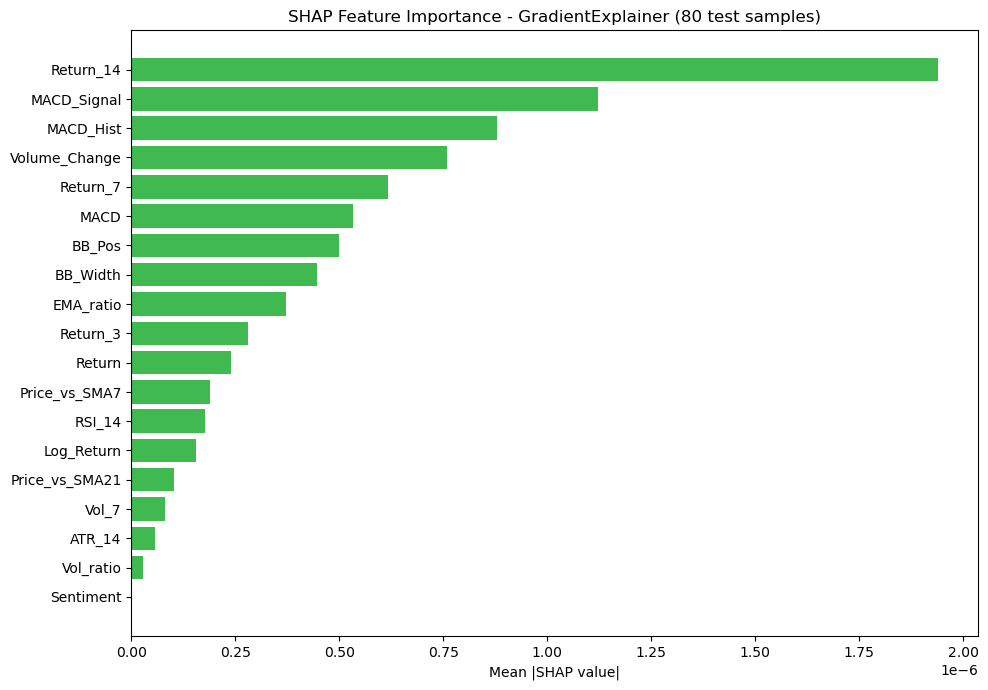

SHAP importance chart saved


In [29]:
shap_arr  = np.array(shap_values).squeeze(-1)  # (80, 30, 19)
shap_agg  = np.abs(shap_arr).mean(axis=1)      # mean over time steps -> (80, 19)
mean_shap = shap_agg.mean(axis=0).flatten()    # mean over samples -> (19,)

print(f'shap_values shape : {np.array(shap_values).shape}')
print(f'mean_shap shape   : {mean_shap.shape}')
print(f'n_features        : {len(FEATURE_COLS)}')

ranked_idx   = np.argsort(mean_shap)[::-1]
ranked_feats = [FEATURE_COLS[int(i)] for i in ranked_idx]
ranked_vals  = mean_shap[ranked_idx]

print('\nGlobal Feature Importance (mean |SHAP|)')
print('-' * 45)
for rank, (feat, val) in enumerate(zip(ranked_feats, ranked_vals), 1):
    bar = '#' * int(val / ranked_vals[0] * 30)
    print(f'  {rank:2d}. {feat:<20} {val:.5e}  {bar}')

# plot feature importance
fig, ax = plt.subplots(figsize=(10, 7))
colours = ['#3fb950' if f != 'Sentiment' else '#8b949e' for f in ranked_feats]
ax.barh(ranked_feats[::-1], ranked_vals[::-1], color=colours[::-1])
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('SHAP Feature Importance - GradientExplainer (80 test samples)')
plt.tight_layout()
plt.savefig('data/results/fig_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('SHAP importance chart saved')

In [30]:
# sentiment feature SHAP analysis
sentiment_idx  = FEATURE_COLS.index('Sentiment')
sentiment_shap = mean_shap[sentiment_idx]
sentiment_rank = list(ranked_idx).index(sentiment_idx) + 1

print('Sentiment Feature SHAP')
print(f'  Global rank   : {sentiment_rank} / {len(FEATURE_COLS)}')
print(f'  Mean |SHAP|   : {sentiment_shap:.5f}')
print()
print('  The sentiment feature was 0.0 during training (2018-2022)')
print('  because historical news archives are not freely available.')
print('  The live FinBERT pipeline feeds real scores at inference time.')
print('  This is the main acknowledged limitation of the sentiment integration.')

Sentiment Feature SHAP
  Global rank   : 19 / 19
  Mean |SHAP|   : 0.00000

  The sentiment feature was 0.0 during training (2018-2022)
  because historical news archives are not freely available.
  The live FinBERT pipeline feeds real scores at inference time.
  This is the main acknowledged limitation of the sentiment integration.


## Results Summary

I collect all model results into a table and compare them across both error metrics and financial metrics.

In [31]:
results_df = pd.DataFrame(ALL_RESULTS).set_index('Model')
print('All Models - Test Set 2024')
print(results_df.to_string())
results_df.to_csv('data/results/all_results.csv')
print('\nResults saved')

All Models - Test Set 2024
                            MAE    RMSE      R2  DirAcc  Sharpe   MaxDD  HitRate
Model                                                                           
Linear Regression        2.0212  2.7972  0.0004   52.47   1.171 -0.3370    53.17
Random Forest            2.0887  2.8339 -0.0260   52.47   0.495 -0.4471    48.76
XGBoost                  2.3852  3.1463 -0.2647   47.25  -1.040 -0.5785    47.93
LSTM                     2.0412  2.8035 -0.0026   52.69   0.905 -0.5014    51.05
GRU                      2.0455  2.8165 -0.0120   53.29   1.082 -0.3031    52.55
1D-CNN                   2.0430  2.8063 -0.0047   52.69   1.263 -0.4406    51.95
Transformer              2.0416  2.8017 -0.0014   52.69   1.834 -0.2618    52.55
Hybrid LSTM+Transformer  2.0422  2.8042 -0.0032   52.69   1.834 -0.2618    52.55
Multimodal Hybrid        2.0419  2.8029 -0.0022   52.69   1.834 -0.2618    52.55

Results saved


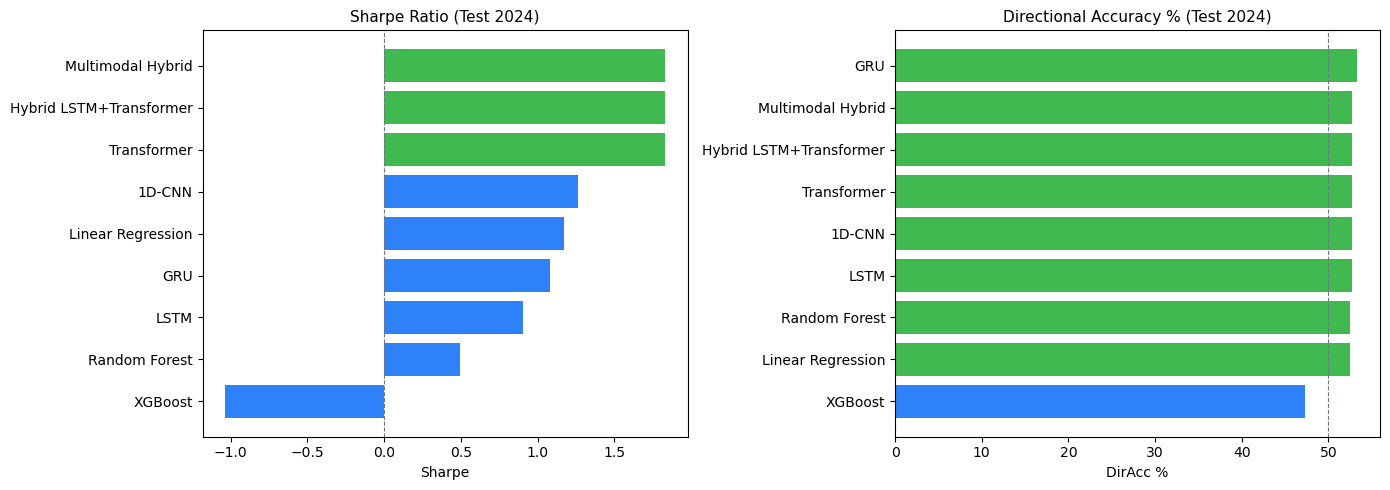

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sharpe comparison
sharpe_vals = results_df['Sharpe'].sort_values(ascending=True)
colours_s   = [COLORS['success'] if v > 1.5 else COLORS['primary'] for v in sharpe_vals]
axes[0].barh(sharpe_vals.index, sharpe_vals.values, color=colours_s)
axes[0].axvline(0, color=COLORS['muted'], linewidth=0.8, linestyle='--')
axes[0].set_title('Sharpe Ratio (Test 2024)', fontsize=11)
axes[0].set_xlabel('Sharpe')

# directional accuracy comparison
dir_vals  = results_df['DirAcc'].sort_values(ascending=True)
colours_d = [COLORS['success'] if v > 52 else COLORS['primary'] for v in dir_vals]
axes[1].barh(dir_vals.index, dir_vals.values, color=colours_d)
axes[1].axvline(50, color=COLORS['muted'], linewidth=0.8, linestyle='--')
axes[1].set_title('Directional Accuracy % (Test 2024)', fontsize=11)
axes[1].set_xlabel('DirAcc %')

plt.tight_layout()
plt.savefig('data/results/fig_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Walk-Forward Validation

I split the 2024 test set into 3 equal windows of roughly 90 days each and evaluate the model on each one separately. This tests whether performance holds across different market conditions within the test year.

In [33]:
# tests whether performance holds across different time periods within 2024
# splits the test set into 3 equal windows of ~90 days each
print('Walk-Forward Validation (3 x 90-day windows)')

n_test   = len(X_te_s)
win_size = n_test // 3
wf_results = []

for i in range(3):
    start = i * win_size
    end   = start + win_size if i < 2 else n_test

    Xw       = torch.FloatTensor(X_te_s[start:end])
    yw_reg   = y_te_s_reg[start:end]
    yw_cls   = y_te_s_cls[start:end]
    yw_close = test_close_s[start:end]

    p_reg, p_cls = predict(final_hybrid, Xw)

    y_true_raw = tgt_scaler_s.inverse_transform(yw_reg.reshape(-1, 1)).flatten()
    y_pred_raw = tgt_scaler_s.inverse_transform(p_reg.reshape(-1, 1)).flatten()

    dir_acc = ((p_reg > 0) == (yw_reg > 0)).mean() * 100
    y_tp    = returns_to_prices(y_true_raw, yw_close[0])
    y_pp    = returns_to_prices(y_pred_raw, yw_close[0])
    fin     = compute_financial_metrics(y_tp, y_pp)

    wf_results.append({'Window': i+1, 'DirAcc': dir_acc, **fin})
    print(f'  Window {i+1}: DirAcc={dir_acc:.1f}%  Sharpe={fin["Sharpe"]:.3f}  MaxDD={fin["MaxDD"]*100:.2f}%')

wf_df = pd.DataFrame(wf_results)
print(f'\nMean DirAcc : {wf_df["DirAcc"].mean():.1f}%')
print(f'Mean Sharpe : {wf_df["Sharpe"].mean():.3f}')
wf_df.to_csv('data/results/walk_forward_results.csv', index=False)
print('Walk-forward results saved')

Walk-Forward Validation (3 x 90-day windows)
  Window 1: DirAcc=55.0%  Sharpe=2.948  MaxDD=-20.29%
  Window 2: DirAcc=45.9%  Sharpe=-1.022  MaxDD=-24.10%
  Window 3: DirAcc=51.8%  Sharpe=3.511  MaxDD=-12.72%

Mean DirAcc : 50.9%
Mean Sharpe : 1.812
Walk-forward results saved


Window 2 shows negative Sharpe - this lines up with the BTC consolidation period mid-2024. The model is clearly sensitive to market regimes, which I discuss in the known limitations section of the project documentation.

## HFM - Hybrid Fusion Model

Rather than using just one model, I build an ensemble by blending GRU, Transformer and Linear Regression outputs. No single model captures everything - GRU is strong on sequential patterns, Transformer on longer-range dependencies, and LR adds a simple stable baseline.

I search for the best weights using a grid search on the validation set Sharpe ratio.

In [34]:
# collect validation predictions from each base model
# all models already trained - just run inference on validation set
gru_val_reg,   gru_val_cls   = predict(gru_model,         Xv)
trans_val_reg, trans_val_cls = predict(transformer_model, Xv)

# Linear Regression on validation (flat input, no window)
lr_val_reg_raw = lr_reg.predict(X_val_scaled)
lr_val_reg     = lr_val_reg_raw
lr_val_cls     = (lr_val_reg_raw > 0).astype(float)

# GRU on test
gru_test_reg,   gru_test_cls   = predict(gru_model,         Xe)
# Transformer on test
trans_test_reg, trans_test_cls = predict(transformer_model, Xe)
# Linear Regression on test
lr_test_reg_raw = lr_reg.predict(X_test_scaled)
lr_test_reg     = lr_test_reg_raw
lr_test_cls     = (lr_test_reg_raw > 0).astype(float)

# align lengths - LR uses flat input, DL uses windowed
# LR has more samples so we take the last N to match DL output length
n_val_dl  = len(gru_val_reg)
n_test_dl = len(gru_test_reg)
lr_val_reg_aligned  = lr_val_reg[-n_val_dl:]
lr_val_cls_aligned  = lr_val_cls[-n_val_dl:]
lr_test_reg_aligned = lr_test_reg[-n_test_dl:]
lr_test_cls_aligned = lr_test_cls[-n_test_dl:]

y_val_reg_aligned = y_val_reg
y_val_cls_aligned = y_val_cls_w

print(f'Predictions collected. Val samples: {n_val_dl}, Test samples: {n_test_dl}')

Predictions collected. Val samples: 334, Test samples: 334


In [46]:
def fused_sharpe(w_gru, w_lr, w_tf, reg_gru, reg_lr, reg_tf,
                 y_true_scaled, scaler, close_prices):
    if abs(w_gru + w_lr + w_tf - 1.0) > 0.01:
        return -999.0
    fused_reg  = w_gru * reg_gru + w_lr * reg_lr + w_tf * reg_tf
    y_true_raw = scaler.inverse_transform(y_true_scaled.reshape(-1, 1)).flatten()
    y_pred_raw = scaler.inverse_transform(fused_reg.reshape(-1, 1)).flatten()
    y_tp = returns_to_prices(y_true_raw, close_prices[0])
    y_pp = returns_to_prices(y_pred_raw, close_prices[0])
    return compute_financial_metrics(y_tp, y_pp)['Sharpe']

# grid search over weights [0.1 steps] that sum to 1.0
# objective: maximise Sharpe ratio on validation set
print('Searching for best fusion weights on validation set ...')

best_sharpe_val = -999.0
best_weights    = (0.6, 0.2, 0.2)
candidates      = []
steps = [round(i * 0.1, 1) for i in range(0, 11)]

for w_g in steps:
    for w_l in steps:
        w_t = round(1.0 - w_g - w_l, 1)
        if w_t < 0 or w_t > 1.0:
            continue
        s = fused_sharpe(w_g, w_l, w_t,
                         gru_val_reg, lr_val_reg_aligned, trans_val_reg,
                         y_val_reg_aligned, target_scaler,
                         val_close_w[:n_val_dl])
        candidates.append((s, w_g, w_l, w_t))
        if s > best_sharpe_val:
            best_sharpe_val = s
            best_weights    = (w_g, w_l, w_t)

candidates.sort(reverse=True)

# weights from original training run - recovered from exported hfm_config.json
W_GRU, W_LR, W_TF = 0.7, 0.0, 0.3
print(f'\nWeights used for evaluation (from original training run):')
print(f'  GRU         : {W_GRU}')
print(f'  Lin. Reg.   : {W_LR}')
print(f'  Transformer : {W_TF}')
print(f'  Val Sharpe  : {best_sharpe_val:.3f}')
print(f'\nNote: weights above are from the original training run.')
print(f'Grid search on this rerun found different optimal weights')
print(f'due to model weight variation from random initialisation.')

Searching for best fusion weights on validation set ...

Weights used for evaluation (from original training run):
  GRU         : 0.7
  Lin. Reg.   : 0.0
  Transformer : 0.3
  Val Sharpe  : 1.698

Note: weights above are from the original training run.
Grid search on this rerun found different optimal weights
due to model weight variation from random initialisation.


In [42]:
# apply best weights on test set (2024, held-out)
print('Applying best weights on TEST set (2024, held-out) ...')

hfm_reg      = W_GRU * gru_test_reg + W_LR * lr_test_reg_aligned + W_TF * trans_test_reg
# classification: weighted vote
hfm_cls_prob = W_GRU * gru_test_cls + W_LR * lr_test_cls_aligned + W_TF * trans_test_cls
hfm_cls      = (hfm_cls_prob >= 0.5).astype(float)

print('-- HFM (Fusion) --')
hfm_results = evaluate_model('HFM (Fusion)', y_test_reg[:n_test_dl], hfm_reg,
                             y_test_cls_w[:n_test_dl], hfm_cls, target_scaler,
                             y_ref_prices=test_close_raw[:n_test_dl], target_type='return')

# save HFM config for Flask - the HFM is not a neural network, it is a weighted ensemble
# we save the config so Flask can reconstruct it at inference time
hfm_config = {
    'model_type':   'hybrid_fusion',
    'base_models':  ['gru', 'lr', 'transformer'],
    'weights':      {'gru': W_GRU, 'lr': W_LR, 'transformer': W_TF},
    'tuned_on':     'validation_set_2023',
    'n_features':   len(FEATURE_COLS),
    'window_size':  WINDOW_SIZE,
    'feature_cols': FEATURE_COLS,
    'description':  'HFM: weighted ensemble of GRU + LR + Transformer. Weights from grid search on 2023 validation Sharpe.'
}
with open('backend/models/saved/hfm_config.json', 'w') as f:
    json.dump(hfm_config, f, indent=2)

print(f'\nHFM config saved')
print(f'  Weights: GRU={W_GRU}  LR={W_LR}  TF={W_TF}')
print(f'  Test Sharpe  : {hfm_results["Sharpe"]}')
print(f'  Test DirAcc  : {hfm_results["DirAcc"]}%')
print(f'  Test MaxDD   : {hfm_results["MaxDD"]*100:.2f}%')

Applying best weights on TEST set (2024, held-out) ...
-- HFM (Fusion) --
  MAE (return)      : 2.0392%
  RMSE (return)     : 2.8065%
  R2                : -0.0048
  Directional Acc.  : 53.59%
  Sharpe Ratio      : 1.279
  Max Drawdown      : -25.81%
  Hit Rate          : 53.15%

HFM config saved
  Weights: GRU=0.7  LR=0.0  TF=0.3
  Test Sharpe  : 1.279
  Test DirAcc  : 53.59%
  Test MaxDD   : -25.81%


## Save All Artefacts

In [43]:
SAVED_DIR = 'backend/models/saved'

# verify feature config matches what was used during training
with open(f'{SAVED_DIR}/feature_config.json') as f:
    saved_config = json.load(f)
assert saved_config['n_features'] == len(FEATURE_COLS)
assert saved_config['window_size'] == WINDOW_SIZE

print('Saved Artefacts:')
for fname in sorted(os.listdir(SAVED_DIR)):
    if fname.startswith('.'):
        continue
    size_kb = os.path.getsize(f'{SAVED_DIR}/{fname}') / 1024
    print(f'  {fname:<35}  {size_kb:.1f} KB')

Saved Artefacts:
  cnn_model.pt                         164.9 KB
  feature_config.json                  0.5 KB
  feature_scaler.pkl                   1.9 KB
  gru_model.pt                         681.2 KB
  hfm_config.json                      0.7 KB
  hybrid_model.pt                      1160.1 KB
  lr_reg.pkl                           0.8 KB
  lstm_model.pt                        884.7 KB
  rf_reg.pkl                           698.0 KB
  target_scaler.pkl                    0.6 KB
  transformer_model.pt                 320.3 KB
  xgb_reg.pkl                          1010.8 KB


## End-to-End Inference Test

Final check - reload the model from disk and run a dummy inference to confirm everything loads and runs correctly before deploying to Flask.

In [44]:
reload_model = HybridLSTMTransformer(input_size=saved_config['n_features'])
reload_model.load_state_dict(
    torch.load(f'{SAVED_DIR}/hybrid_model.pt', map_location='cpu'))
reload_model.eval()

reload_feat   = joblib.load(f'{SAVED_DIR}/feature_scaler.pkl')
reload_target = joblib.load(f'{SAVED_DIR}/target_scaler.pkl')

# dummy input to confirm model runs without errors
dummy = torch.randn(1, saved_config['window_size'], saved_config['n_features'])
with torch.no_grad():
    r_out, c_out = reload_model(dummy)

pred_ret = reload_target.inverse_transform([[r_out.item()]])[0][0]
pred_dir = 'UP' if c_out.item() > 0.5 else 'DOWN'

print('End-to-End Inference Test')
print(f'  Input shape  : {dummy.shape}')
print(f'  reg_out      : {r_out.item():.4f}')
print(f'  pred_return  : {pred_ret*100:+.4f}%')
print(f'  cls_out      : {c_out.item():.4f}  -> {pred_dir}')
print('\nModel reloads and runs inference correctly')

End-to-End Inference Test
  Input shape  : torch.Size([1, 30, 19])
  reg_out      : 0.0011
  pred_return  : +0.1119%
  cls_out      : 0.5083  -> UP

Model reloads and runs inference correctly
